# Companion Notebook

## Dual-Network PINNs for Optimal Control: A Reproducible Benchmark on the Mass--Spring--Damper System

**Author:** Abdeladhim Tahimi  
**Year:** 2026  
**License:** MIT  
**Archive (DOI):** [10.5281/zenodo.XXXXXXXX](https://doi.org/10.5281/zenodo.XXXXXXXX)  
**Repository:** https://github.com/Tahimi/PINN-MSD-Optimal-Control

---

### About this notebook

This notebook is the **official companion artifact** of the manuscript *Dual-Network PINNs for Optimal Control: A Reproducible Benchmark on the Mass--Spring--Damper System*. It implements the complete computational pipeline used to produce every numerical result, table, and figure of the paper.

### What it does

The notebook solves a linear-quadratic optimal control problem on a mass--spring--damper system using **three independent methods**:

1. **Pontryagin's Minimum Principle (PMP)** via single shooting -- the gold reference solution.
2. **Direct transcription via trapezoidal collocation** solved as an NLP -- a second independent classical reference.
3. **Dual-network Physics-Informed Neural Network (PINN)** with hard boundary-condition enforcement on the state and an unconstrained control network.

All three methods are evaluated on a common dense reference grid; the PINN is validated against the two classical references via pointwise errors and a comparison of the achieved cost.

### Reproducibility

A fixed random seed (`SEED = 42`) is used throughout. All numerical results are saved to a single CSV file in `results/`. All figures are saved to `figures/`. Each figure cell can be re-executed independently by reading the CSV back from disk, so individual figures can be regenerated without re-running the training pipeline.

### Figure style

Figures are grayscale and use distinct markers (no color) so they remain legible in black-and-white print.

### How to cite

If you use this notebook in research, please cite **both** the paper and this software archive. BibTeX entries are provided in the repository `README.md`.

---

## 1. Mount Google Drive and prepare project folders

In [1]:
# Mount Google Drive and create the project's input/output folders.
# The notebook itself is assumed to live inside PROJECT_ROOT.
# Adjust PROJECT_ROOT to point at the folder where you keep this notebook.

from google.colab import drive
import os

drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = '/content/drive/MyDrive/PINN_MSD'   # <-- change if needed
FIGURES_DIR  = os.path.join(PROJECT_ROOT, 'figures')
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.makedirs(FIGURES_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR,  exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Figures dir  :', FIGURES_DIR)
print('Results dir  :', RESULTS_DIR)

Mounted at /content/drive
Project root : /content/drive/MyDrive/PINN_MSD
Figures dir  : /content/drive/MyDrive/PINN_MSD/figures
Results dir  : /content/drive/MyDrive/PINN_MSD/results


## 2. Imports, global configuration, and reproducibility seed

In [2]:
# Standard library and scientific stack imports.
# A single global seed is set for numpy, torch (CPU+CUDA), and Python's random module.

import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize  import root, minimize
from scipy.interpolate import CubicSpline

import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float64   # float64 for accuracy in this small problem
torch.set_default_dtype(DTYPE)

print('PyTorch  :', torch.__version__)
print('NumPy    :', np.__version__)
print('Device   :', DEVICE)
print('Dtype    :', DTYPE)
print('Seed     :', SEED)

PyTorch  : 2.10.0+cu128
NumPy    : 2.0.2
Device   : cuda
Dtype    : torch.float64
Seed     : 42


## 3. Problem parameters

All physical and numerical parameters are defined once, matching Table 1 of the manuscript.

In [11]:
# Physical and numerical parameters of the optimal control problem.
# These values match Table 1 of the manuscript.

# Physical parameters
m   = 1.0      # mass            [kg]
c   = 1.0      # damping         [N s / m]
k   = 1.0      # spring const.   [N / m]
r   = 0.1      # control weight  [-]

# Time horizon and boundary conditions
T   = 5.0      # final time      [s]
x0  = 1.0      # initial displacement [m]
v0  = 0.0      # initial velocity     [m/s]
xT  = 0.0      # terminal displacement [m]
vT  = 0.0      # terminal velocity     [m/s]

# Plotting grid (sparse) and reference grid (dense)
# The dense grid is used to evaluate all methods and compute error norms.
# The plotting grid is obtained by subsampling every PLOT_STRIDE-th point
# of the dense grid, so the marker density on figures stays readable.
N_DENSE     = 501          # 501 points  -> step 0.01 on [0, 5]
PLOT_STRIDE = 10           # plotting grid = every 10th dense point (51 pts)

# Trapezoidal collocation NLP discretization
N_COLLOC = 100             # number of intervals -> 101 nodes

# PINN training collocation points
N_C        = 100
N_LAYERS   = 4
WIDTH      = 32
ADAM_EPOCHS    = 5000
ADAM_LR        = 1e-3
LBFGS_MAX_ITER = 2000
LAMBDA_PHYS    = 1000.0    # weight on the physics-residual loss term

print(f'Damping ratio zeta = {c/(2*math.sqrt(m*k)):.3f}  (underdamped if < 1)')

Damping ratio zeta = 0.500  (underdamped if < 1)


## 4. Classical solution 1 -- Pontryagin's Minimum Principle (single shooting)

The TPBVP derived in Section 3.1 of the manuscript is solved by single shooting. The unknown initial costate vector is determined so that the terminal state constraints are met.

In [5]:
# Indirect method: Pontryagin's Minimum Principle + single shooting.
# State-costate vector: y = [x1, x2, l1, l2]
#   dx1/dt =  x2
#   dx2/dt = -x1 - x2 + u*,   with u* = -l2 / (2r)
#   dl1/dt = -2*x1 + l2
#   dl2/dt = -l1 + l2

def hamiltonian_rhs(t, y):
    x1, x2, l1, l2 = y
    u_star = -l2 / (2.0 * r)
    return [
        x2,
        -x1 - x2 + u_star,
        -2.0 * x1 + l2,
        -l1 + l2,
    ]

def shooting_residual(s):
    '''Integrate forward from initial state with guessed costate s = (l1(0), l2(0))
    and return the deviation of the terminal state from the desired (0, 0).'''
    y0 = [x0, v0, s[0], s[1]]
    sol = solve_ivp(
        hamiltonian_rhs, (0.0, T), y0,
        method='RK45', rtol=1e-12, atol=1e-12, dense_output=False,
    )
    return np.array([sol.y[0, -1] - xT, sol.y[1, -1] - vT])

# Solve for the unknown initial costate by root finding.
t_pmp_start = time.perf_counter()
s0_guess  = np.zeros(2)
root_sol  = root(shooting_residual, s0_guess, method='hybr', tol=1e-12)
l0_star   = root_sol.x
t_pmp     = time.perf_counter() - t_pmp_start

assert root_sol.success, f'PMP shooting failed: {root_sol.message}'
print('Shooting converged. Initial costate l(0) =', l0_star)
print(f'PMP wall-clock time: {t_pmp:.3f} s')

# Integrate once more on the dense plotting grid to recover the full trajectories.
t_dense = np.linspace(0.0, T, N_DENSE)
sol_full = solve_ivp(
    hamiltonian_rhs, (0.0, T), [x0, v0, l0_star[0], l0_star[1]],
    t_eval=t_dense, method='RK45', rtol=1e-12, atol=1e-12,
)
x_pmp  = sol_full.y[0]
v_pmp  = sol_full.y[1]
l1_pmp = sol_full.y[2]
l2_pmp = sol_full.y[3]
u_pmp  = -l2_pmp / (2.0 * r)

# Quadratic cost J = integral over [0, T] of (x^2 + r u^2) dt, trapezoidal.
J_pmp = np.trapezoid(x_pmp**2 + r * u_pmp**2, t_dense)
print(f'PMP cost J = {J_pmp:.6e}')
print(f'PMP terminal residuals:  |x(T)| = {abs(x_pmp[-1]):.2e},  |v(T)| = {abs(v_pmp[-1]):.2e}')

Shooting converged. Initial costate l(0) = [1.3744177  0.46333434]
PMP wall-clock time: 1.205 s
PMP cost J = 6.872264e-01
PMP terminal residuals:  |x(T)| = 3.76e-15,  |v(T)| = 9.09e-15


## 5. Classical solution 2 -- Direct transcription (trapezoidal collocation)

The state and control are discretized on a uniform grid and the trapezoidal collocation equations are enforced as equality constraints in a finite-dimensional NLP.

In [6]:
# Direct transcription: discretize x_i, v_i, u_i on a uniform grid t_i = i*h, i=0..N
# Decision vector z = [x_0, v_0, ..., x_N, v_N, u_0, ..., u_N]
#   trapezoidal collocation:
#       x_{i+1} - x_i = h/2 (v_i + v_{i+1})
#       v_{i+1} - v_i = h/2 [ (-x_i - v_i + u_i) + (-x_{i+1} - v_{i+1} + u_{i+1}) ]
#   trapezoidal quadrature of cost.
# Solved with scipy.optimize.minimize, SLSQP, with equality constraints.

N  = N_COLLOC
h  = T / N
t_col = np.linspace(0.0, T, N + 1)

def split_z(z):
    x = z[0 : N + 1]
    v = z[N + 1 : 2 * (N + 1)]
    u = z[2 * (N + 1) : 3 * (N + 1)]
    return x, v, u

def nlp_cost(z):
    x, v, u = split_z(z)
    f = x**2 + r * u**2
    return 0.5 * h * (f[0] + 2.0 * f[1:-1].sum() + f[-1])

def nlp_cost_grad(z):
    x, v, u = split_z(z)
    g = np.zeros_like(z)
    w = np.full(N + 1, h)
    w[0]  = 0.5 * h
    w[-1] = 0.5 * h
    g[0 : N + 1]                     = 2.0 * w * x
    g[2 * (N + 1) : 3 * (N + 1)]     = 2.0 * w * r * u
    return g

def nlp_dynamics_cons(z):
    '''All collocation equality constraints concatenated, plus boundary conditions.'''
    x, v, u = split_z(z)
    cons = []
    # Initial conditions
    cons.append(x[0] - x0)
    cons.append(v[0] - v0)
    # Trapezoidal collocation
    for i in range(N):
        f_v_i   = -x[i]   - v[i]   + u[i]
        f_v_ip1 = -x[i+1] - v[i+1] + u[i+1]
        cons.append( x[i+1] - x[i] - 0.5 * h * (v[i] + v[i+1]) )
        cons.append( v[i+1] - v[i] - 0.5 * h * (f_v_i + f_v_ip1) )
    # Terminal conditions
    cons.append(x[-1] - xT)
    cons.append(v[-1] - vT)
    return np.array(cons)

z0 = np.zeros(3 * (N + 1))
z0[0 : N + 1] = np.linspace(x0, xT, N + 1)   # linear initial guess for x

t_col_start = time.perf_counter()
res = minimize(
    nlp_cost, z0, jac=nlp_cost_grad, method='SLSQP',
    constraints={'type': 'eq', 'fun': nlp_dynamics_cons},
    options={'ftol': 1e-12, 'maxiter': 500, 'disp': False},
)
t_collocation = time.perf_counter() - t_col_start

assert res.success, f'NLP failed: {res.message}'
x_col_grid, v_col_grid, u_col_grid = split_z(res.x)

# Interpolate onto the dense plotting/reference grid via cubic spline.
x_col = CubicSpline(t_col, x_col_grid)(t_dense)
v_col = CubicSpline(t_col, v_col_grid)(t_dense)
u_col = CubicSpline(t_col, u_col_grid)(t_dense)

J_col = np.trapezoid(x_col**2 + r * u_col**2, t_dense)
print(f'Collocation cost J = {J_col:.6e}')
print(f'Collocation time   = {t_collocation:.3f} s')
print(f'Collocation terminal residuals:  |x(T)| = {abs(x_col_grid[-1]):.2e},  |v(T)| = {abs(v_col_grid[-1]):.2e}')

Collocation cost J = 6.881065e-01
Collocation time   = 10.420 s
Collocation terminal residuals:  |x(T)| = 0.00e+00,  |v(T)| = 0.00e+00


## 6. PINN solution -- network classes

Two independent MLPs with `tanh` activations. The state network is wrapped by the composite ansatz $\hat x(t) = \phi(t) + \psi(t)\,\mathcal F_x(t)$ to enforce all four boundary conditions exactly.

In [7]:
# Dual-network PINN definition.
# - MLP: L hidden layers of width W, tanh activations, linear output.
# - State ansatz: x_hat(t) = phi(t) + psi(t) * N_x(t),
#       phi(t) = 1 - 3*(t/T)^2 + 2*(t/T)^3   (cubic, satisfies all 4 BCs)
#       psi(t) = t^2 (T - t)^2 / T^4         (mask, vanishes to 1st order at both ends)
# - Control ansatz: u_hat(t) = N_u(t)        (unconstrained).

def glorot_init(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

class MLP(nn.Module):
    def __init__(self, n_layers=N_LAYERS, width=WIDTH):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self.apply(glorot_init)
    def forward(self, t):
        return self.net(t)

def phi_fn(t):
    return 1.0 - 3.0 * (t / T) ** 2 + 2.0 * (t / T) ** 3

def psi_fn(t):
    return (t ** 2) * (T - t) ** 2 / (T ** 4)

def x_hat(net_x, t):
    return phi_fn(t) + psi_fn(t) * net_x(t)

def u_hat(net_u, t):
    return net_u(t)

# Sanity check on the ansatz at t = 0 and t = T (purely symbolic, network is random).
torch.manual_seed(SEED)
_net_x = MLP().to(DEVICE)
for tt in [0.0, T]:
    tt_tensor = torch.tensor([[tt]], device=DEVICE, dtype=DTYPE, requires_grad=True)
    xv = x_hat(_net_x, tt_tensor)
    dx = torch.autograd.grad(xv, tt_tensor, torch.ones_like(xv), create_graph=False)[0]
    print(f't={tt:.1f}:  x_hat = {xv.item(): .6e},  dx_hat/dt = {dx.item(): .6e}')

t=0.0:  x_hat =  1.000000e+00,  dx_hat/dt =  0.000000e+00
t=5.0:  x_hat =  0.000000e+00,  dx_hat/dt =  0.000000e+00


In [8]:
# Interior probe of the ansatz: confirms x_hat(t) is not collapsed
# and that the network contribution psi(t) * N_x(t) is active inside (0, T).
# This still uses the random (untrained) network from the previous cell.

print(f'{"t":>6} | {"phi(t)":>12} | {"psi(t)":>12} | {"N_x(t)":>14} | {"x_hat(t)":>14} | {"dx_hat/dt":>14}')
print('-' * 84)
for tt in [0.0, 0.5, 1.0, 2.5, 4.0, 4.5, 5.0]:
    tt_tensor = torch.tensor([[tt]], device=DEVICE, dtype=DTYPE, requires_grad=True)
    raw  = _net_x(tt_tensor)                                    # N_x(t)
    xv   = x_hat(_net_x, tt_tensor)                             # phi + psi * N_x
    dxv  = torch.autograd.grad(xv, tt_tensor, torch.ones_like(xv), create_graph=False)[0]
    phi_v = phi_fn(torch.tensor(tt, dtype=DTYPE)).item()
    psi_v = psi_fn(torch.tensor(tt, dtype=DTYPE)).item()
    print(f'{tt:>6.2f} | {phi_v:>12.4e} | {psi_v:>12.4e} | {raw.item():>14.4e} | {xv.item():>14.4e} | {dxv.item():>14.4e}')

     t |       phi(t) |       psi(t) |         N_x(t) |       x_hat(t) |      dx_hat/dt
------------------------------------------------------------------------------------
  0.00 |   1.0000e+00 |   0.0000e+00 |     0.0000e+00 |     1.0000e+00 |     0.0000e+00
  0.50 |   9.7200e-01 |   8.1000e-03 |     1.3208e-01 |     9.7307e-01 |    -1.0219e-01
  1.00 |   8.9600e-01 |   2.5600e-02 |     2.4491e-01 |     9.0227e-01 |    -1.7736e-01
  2.50 |   5.0000e-01 |   6.2500e-02 |     4.7925e-01 |     5.2995e-01 |    -2.9264e-01
  4.00 |   1.0400e-01 |   2.5600e-02 |     6.1999e-01 |     1.1987e-01 |    -2.1389e-01
  4.50 |   2.8000e-02 |   8.1000e-03 |     6.5506e-01 |     3.3306e-02 |    -1.2633e-01
  5.00 |   0.0000e+00 |   0.0000e+00 |     6.8591e-01 |     0.0000e+00 |     0.0000e+00


## 7. PINN solution -- training (Adam then L-BFGS)

Unweighted sum of physics residual loss and trapezoidal cost approximation. Adam warm-up followed by L-BFGS refinement.

In [12]:
# PINN training: minimize L = LAMBDA_PHYS * L_phys + L_cost.
#   L_phys = (1/N_c) sum_i [ x_hat'' + x_hat' + x_hat - u_hat ]^2  at collocation points
#   L_cost = trapezoidal quadrature of  x_hat^2 + r u_hat^2  on the same grid
# Both component losses are still recorded individually in the history.

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

net_x = MLP().to(DEVICE)
net_u = MLP().to(DEVICE)

t_col_pinn = torch.linspace(0.0, T, N_C, device=DEVICE, dtype=DTYPE).reshape(-1, 1)
t_col_pinn.requires_grad_(True)
h_pinn = T / (N_C - 1)

def losses():
    x_val = x_hat(net_x, t_col_pinn)
    u_val = u_hat(net_u, t_col_pinn)
    dx  = torch.autograd.grad(x_val, t_col_pinn, torch.ones_like(x_val), create_graph=True)[0]
    ddx = torch.autograd.grad(dx,    t_col_pinn, torch.ones_like(dx),    create_graph=True)[0]
    residual = ddx + dx + x_val - u_val            # m=k=c=1
    L_phys = (residual ** 2).mean()
    f = x_val ** 2 + r * u_val ** 2
    L_cost = 0.5 * h_pinn * (f[0] + 2.0 * f[1:-1].sum() + f[-1]).squeeze()
    return L_phys, L_cost

# -------------------------------------------------
# Phase 1: Adam
# -------------------------------------------------
params = list(net_x.parameters()) + list(net_u.parameters())
opt_adam = torch.optim.Adam(params, lr=ADAM_LR)

history = {'epoch': [], 'L_phys': [], 'L_cost': [], 'L_total': []}

t_adam_start = time.perf_counter()
for epoch in range(ADAM_EPOCHS):
    opt_adam.zero_grad()
    L_phys, L_cost = losses()
    L = LAMBDA_PHYS * L_phys + L_cost
    L.backward()
    opt_adam.step()
    if epoch % 100 == 0 or epoch == ADAM_EPOCHS - 1:
        history['epoch'].append(epoch)
        history['L_phys'].append(L_phys.item())
        history['L_cost'].append(L_cost.item())
        history['L_total'].append(L.item())
    if epoch % 1000 == 0:
        print(f'[Adam ] epoch {epoch:5d}  L = {L.item():.4e}   L_phys = {L_phys.item():.4e}   L_cost = {L_cost.item():.4e}')
t_adam = time.perf_counter() - t_adam_start
print(f'Adam phase finished in {t_adam:.2f} s')

# -------------------------------------------------
# Phase 2: L-BFGS
# -------------------------------------------------
opt_lbfgs = torch.optim.LBFGS(
    params, lr=1.0, max_iter=LBFGS_MAX_ITER, tolerance_grad=1e-12,
    tolerance_change=1e-14, history_size=50, line_search_fn='strong_wolfe',
)
lbfgs_iter = {'k': 0}

def closure():
    opt_lbfgs.zero_grad()
    L_phys, L_cost = losses()
    L = LAMBDA_PHYS * L_phys + L_cost
    L.backward()
    k = lbfgs_iter['k']
    if k % 50 == 0:
        history['epoch'].append(ADAM_EPOCHS + k)
        history['L_phys'].append(L_phys.item())
        history['L_cost'].append(L_cost.item())
        history['L_total'].append(L.item())
    lbfgs_iter['k'] += 1
    return L

t_lbfgs_start = time.perf_counter()
opt_lbfgs.step(closure)
t_lbfgs = time.perf_counter() - t_lbfgs_start
print(f'L-BFGS phase finished in {t_lbfgs:.2f} s ({lbfgs_iter["k"]} closure calls)')

# Final loss readout (no torch.no_grad() -- losses() needs autograd for x_hat derivatives).
L_phys_final, L_cost_final = losses()
L_total_final = LAMBDA_PHYS * L_phys_final + L_cost_final
print(f'Final losses:  L_phys = {L_phys_final.item():.4e}   L_cost = {L_cost_final.item():.4e}   L = {L_total_final.item():.4e}')

t_pinn_total = t_adam + t_lbfgs

[Adam ] epoch     0  L = 1.8794e+02   L_phys = 1.8601e-01   L_cost = 1.9286e+00
[Adam ] epoch  1000  L = 1.2538e+00   L_phys = 5.9877e-06   L_cost = 1.2479e+00
[Adam ] epoch  2000  L = 9.4170e-01   L_phys = 6.8434e-07   L_cost = 9.4101e-01
[Adam ] epoch  3000  L = 8.5389e-01   L_phys = 2.2245e-07   L_cost = 8.5367e-01
[Adam ] epoch  4000  L = 8.2530e-01   L_phys = 2.7455e-07   L_cost = 8.2503e-01
Adam phase finished in 79.20 s
L-BFGS phase finished in 45.75 s (2330 closure calls)
Final losses:  L_phys = 6.1675e-08   L_cost = 6.8740e-01   L = 6.8746e-01


## 8. PINN evaluation on the dense reference grid

In [13]:
# Evaluate the trained PINN on the dense reference grid used by PMP and collocation.
# Velocity is obtained by autograd on x_hat (consistent with the manuscript ansatz).

t_dense_torch = torch.tensor(t_dense, device=DEVICE, dtype=DTYPE).reshape(-1, 1)
t_dense_torch.requires_grad_(True)

x_pinn_t = x_hat(net_x, t_dense_torch)
u_pinn_t = u_hat(net_u, t_dense_torch)
v_pinn_t = torch.autograd.grad(x_pinn_t, t_dense_torch, torch.ones_like(x_pinn_t), create_graph=False)[0]

x_pinn = x_pinn_t.detach().cpu().numpy().flatten()
v_pinn = v_pinn_t.detach().cpu().numpy().flatten()
u_pinn = u_pinn_t.detach().cpu().numpy().flatten()

J_pinn = np.trapezoid(x_pinn**2 + r * u_pinn**2, t_dense)
print(f'PINN cost J = {J_pinn:.6e}')
print(f'PINN terminal residuals:  |x(T)| = {abs(x_pinn[-1]):.2e},  |v(T)| = {abs(v_pinn[-1]):.2e}')

PINN cost J = 6.871579e-01
PINN terminal residuals:  |x(T)| = 0.00e+00,  |v(T)| = 0.00e+00


## 9. Save all numerical results to a single CSV

Wide format on the dense reference grid. Figure cells subsample this CSV every `PLOT_STRIDE` rows to obtain the plotting grid.

In [14]:
# All trajectories and pointwise errors are written to a single wide-format CSV
# on the dense reference grid. Figure cells re-read this file and subsample for plotting.

df = pd.DataFrame({
    't'        : t_dense,
    'x_pmp'    : x_pmp,
    'v_pmp'    : v_pmp,
    'u_pmp'    : u_pmp,
    'x_col'    : x_col,
    'v_col'    : v_col,
    'u_col'    : u_col,
    'x_pinn'   : x_pinn,
    'v_pinn'   : v_pinn,
    'u_pinn'   : u_pinn,
    'err_x_pinn_vs_pmp': np.abs(x_pinn - x_pmp),
    'err_v_pinn_vs_pmp': np.abs(v_pinn - v_pmp),
    'err_u_pinn_vs_pmp': np.abs(u_pinn - u_pmp),
    'err_x_pinn_vs_col': np.abs(x_pinn - x_col),
    'err_v_pinn_vs_col': np.abs(v_pinn - v_col),
    'err_u_pinn_vs_col': np.abs(u_pinn - u_col),
    'err_x_col_vs_pmp' : np.abs(x_col  - x_pmp),
    'err_v_col_vs_pmp' : np.abs(v_col  - v_pmp),
    'err_u_col_vs_pmp' : np.abs(u_col  - u_pmp),
})

csv_path = os.path.join(RESULTS_DIR, 'trajectories.csv')
df.to_csv(csv_path, index=False)
print(f'Saved {len(df)} rows and {df.shape[1]} columns to:\n  {csv_path}')

# Also save the PINN loss history as its own small CSV (different x-axis).
loss_df = pd.DataFrame(history)
loss_path = os.path.join(RESULTS_DIR, 'loss_history.csv')
loss_df.to_csv(loss_path, index=False)
print(f'Saved {len(loss_df)} rows to:\n  {loss_path}')

Saved 501 rows and 19 columns to:
  /content/drive/MyDrive/PINN_MSD/results/trajectories.csv
Saved 98 rows to:
  /content/drive/MyDrive/PINN_MSD/results/loss_history.csv


## 10. Results and statistics

A single human-readable summary of all numbers the manuscript needs. This cell is self-contained: removing the *next* (manuscript-formatting) cell loses no information.

In [15]:
# Human-readable summary of all numerical results.
# Numbers are read back from the CSV files for full reproducibility,
# so this cell does NOT depend on variables left over from earlier cells.

_df  = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))
_ldf = pd.read_csv(os.path.join(RESULTS_DIR, 'loss_history.csv'))

_t = _df['t'].values

def _L2(e):
    return float(np.sqrt(np.trapezoid(e**2, _t)))
def _Linf(e):
    return float(np.max(np.abs(e)))
def _J(x, u):
    return float(np.trapezoid(x**2 + r * u**2, _t))

stats = {
    'cost_J': {
        'PMP'        : _J(_df['x_pmp'].values,  _df['u_pmp'].values),
        'Collocation': _J(_df['x_col'].values,  _df['u_col'].values),
        'PINN'       : _J(_df['x_pinn'].values, _df['u_pinn'].values),
    },
    'terminal_residual': {
        'PMP'        : (abs(_df['x_pmp'].iloc[-1]),  abs(_df['v_pmp'].iloc[-1])),
        'Collocation': (abs(_df['x_col'].iloc[-1]),  abs(_df['v_col'].iloc[-1])),
        'PINN'       : (abs(_df['x_pinn'].iloc[-1]), abs(_df['v_pinn'].iloc[-1])),
    },
    'errors_pinn_vs_pmp': {
        'x': (_L2(_df['err_x_pinn_vs_pmp']), _Linf(_df['err_x_pinn_vs_pmp'])),
        'v': (_L2(_df['err_v_pinn_vs_pmp']), _Linf(_df['err_v_pinn_vs_pmp'])),
        'u': (_L2(_df['err_u_pinn_vs_pmp']), _Linf(_df['err_u_pinn_vs_pmp'])),
    },
    'errors_pinn_vs_col': {
        'x': (_L2(_df['err_x_pinn_vs_col']), _Linf(_df['err_x_pinn_vs_col'])),
        'v': (_L2(_df['err_v_pinn_vs_col']), _Linf(_df['err_v_pinn_vs_col'])),
        'u': (_L2(_df['err_u_pinn_vs_col']), _Linf(_df['err_u_pinn_vs_col'])),
    },
    'errors_col_vs_pmp': {
        'x': (_L2(_df['err_x_col_vs_pmp']), _Linf(_df['err_x_col_vs_pmp'])),
        'v': (_L2(_df['err_v_col_vs_pmp']), _Linf(_df['err_v_col_vs_pmp'])),
        'u': (_L2(_df['err_u_col_vs_pmp']), _Linf(_df['err_u_col_vs_pmp'])),
    },
    'pinn_final_losses': {
        'L_phys' : float(_ldf['L_phys'].iloc[-1]),
        'L_cost' : float(_ldf['L_cost'].iloc[-1]),
        'L_total': float(_ldf['L_total'].iloc[-1]),
    },
    'timings_s': {
        'PMP'         : t_pmp,
        'Collocation' : t_collocation,
        'PINN_Adam'   : t_adam,
        'PINN_LBFGS'  : t_lbfgs,
        'PINN_total'  : t_pinn_total,
    },
}

def line(label, value, width=44):
    print(f'  {label:<{width}}{value}')

print('=' * 70)
print('  OPTIMAL COST  J[u*]  (lower is better)')
print('=' * 70)
for k, v in stats['cost_J'].items():
    line(k, f'{v:.6e}')

print()
print('=' * 70)
print('  TERMINAL CONSTRAINT RESIDUALS  ( |x(T)|, |v(T)| )')
print('=' * 70)
for k, (a, b) in stats['terminal_residual'].items():
    line(k, f'|x(T)| = {a:.2e},  |v(T)| = {b:.2e}')

print()
print('=' * 70)
print('  PINN  vs  PMP   pointwise errors  (L2, Linf)')
print('=' * 70)
for k, (a, b) in stats['errors_pinn_vs_pmp'].items():
    line(f'{k}(t)', f'L2 = {a:.2e},  Linf = {b:.2e}')

print()
print('=' * 70)
print('  PINN  vs  Collocation   pointwise errors  (L2, Linf)')
print('=' * 70)
for k, (a, b) in stats['errors_pinn_vs_col'].items():
    line(f'{k}(t)', f'L2 = {a:.2e},  Linf = {b:.2e}')

print()
print('=' * 70)
print('  Collocation  vs  PMP   pointwise errors  (L2, Linf)')
print('=' * 70)
for k, (a, b) in stats['errors_col_vs_pmp'].items():
    line(f'{k}(t)', f'L2 = {a:.2e},  Linf = {b:.2e}')

print()
print('=' * 70)
print('  PINN FINAL LOSSES')
print('=' * 70)
for k, v in stats['pinn_final_losses'].items():
    line(k, f'{v:.4e}')

print()
print('=' * 70)
print('  WALL-CLOCK TIMINGS  (seconds)')
print('=' * 70)
for k, v in stats['timings_s'].items():
    line(k, f'{v:.3f}')

  OPTIMAL COST  J[u*]  (lower is better)
  PMP                                         6.872264e-01
  Collocation                                 6.881065e-01
  PINN                                        6.871579e-01

  TERMINAL CONSTRAINT RESIDUALS  ( |x(T)|, |v(T)| )
  PMP                                         |x(T)| = 3.76e-15,  |v(T)| = 9.09e-15
  Collocation                                 |x(T)| = 1.48e-21,  |v(T)| = 8.47e-20
  PINN                                        |x(T)| = 0.00e+00,  |v(T)| = 0.00e+00

  PINN  vs  PMP   pointwise errors  (L2, Linf)
  x(t)                                        L2 = 1.14e-03,  Linf = 9.29e-04
  v(t)                                        L2 = 3.37e-03,  Linf = 3.70e-03
  u(t)                                        L2 = 2.43e-02,  Linf = 1.13e-01

  PINN  vs  Collocation   pointwise errors  (L2, Linf)
  x(t)                                        L2 = 1.36e-03,  Linf = 9.74e-04
  v(t)                                        L2 = 3.51e-03, 

## 11. (Optional) Manuscript-formatting cell

This cell exists *only* to print the same numbers in the exact textual layout used in the manuscript, so that they can be copy-pasted into the assistant for table population. **Deleting this cell loses no information** -- everything above already prints all results.

In [16]:
# Optional helper: re-prints the same numerical results in a compact,
# manuscript-ready text layout. Deleting this cell loses NO data --
# the previous cell already prints everything for human consumption.

_df  = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))
_ldf = pd.read_csv(os.path.join(RESULTS_DIR, 'loss_history.csv'))
_t   = _df['t'].values

def _L2(e):  return float(np.sqrt(np.trapezoid(e**2, _t)))
def _Linf(e): return float(np.max(np.abs(e)))
def _J(x, u): return float(np.trapezoid(x**2 + r * u**2, _t))

print('% ===== Table: Optimal cost and terminal residuals =====')
print('Method        |   J[u*]       |  |x(T)|    |  |v(T)|')
for name, xk, vk, uk in [
    ('PMP',         'x_pmp',  'v_pmp',  'u_pmp'),
    ('Collocation', 'x_col',  'v_col',  'u_col'),
    ('PINN',        'x_pinn', 'v_pinn', 'u_pinn'),
]:
    J  = _J(_df[xk].values, _df[uk].values)
    xT_= abs(_df[xk].iloc[-1])
    vT_= abs(_df[vk].iloc[-1])
    print(f'{name:<13} | {J:.6e} | {xT_:.2e}  | {vT_:.2e}')

print()
print('% ===== Table: pointwise errors (L2 / Linf) =====')
print('Comparison         |  q  |  L2 error    |  Linf error')
for label, suffix in [
    ('PINN vs PMP',        'pinn_vs_pmp'),
    ('PINN vs Collocation','pinn_vs_col'),
    ('Collocation vs PMP', 'col_vs_pmp'),
]:
    for q in ['x', 'v', 'u']:
        col = f'err_{q}_{suffix}'
        print(f'{label:<19}|  {q}  | {_L2(_df[col]):.2e}    | {_Linf(_df[col]):.2e}')
    print('-' * 60)

print()
print('% ===== PINN final losses =====')
print(f'L_phys  = {_ldf["L_phys"].iloc[-1]:.4e}')
print(f'L_cost  = {_ldf["L_cost"].iloc[-1]:.4e}')
print(f'L_total = {_ldf["L_total"].iloc[-1]:.4e}')

print()
print('% ===== Wall-clock timings =====')
print(f'PMP shooting     : {t_pmp:.3f} s')
print(f'Collocation NLP  : {t_collocation:.3f} s')
print(f'PINN Adam phase  : {t_adam:.3f} s')
print(f'PINN L-BFGS phase: {t_lbfgs:.3f} s')
print(f'PINN total       : {t_pinn_total:.3f} s')

% ===== Table: Optimal cost and terminal residuals =====
Method        |   J[u*]       |  |x(T)|    |  |v(T)|
PMP           | 6.872264e-01 | 3.76e-15  | 9.09e-15
Collocation   | 6.881065e-01 | 1.48e-21  | 8.47e-20
PINN          | 6.871579e-01 | 0.00e+00  | 0.00e+00

% ===== Table: pointwise errors (L2 / Linf) =====
Comparison         |  q  |  L2 error    |  Linf error
PINN vs PMP        |  x  | 1.14e-03    | 9.29e-04
PINN vs PMP        |  v  | 3.37e-03    | 3.70e-03
PINN vs PMP        |  u  | 2.43e-02    | 1.13e-01
------------------------------------------------------------
PINN vs Collocation|  x  | 1.36e-03    | 9.74e-04
PINN vs Collocation|  v  | 3.51e-03    | 3.23e-03
PINN vs Collocation|  u  | 1.91e-02    | 4.15e-02
------------------------------------------------------------
Collocation vs PMP |  x  | 9.88e-04    | 1.10e-03
Collocation vs PMP |  v  | 1.59e-03    | 2.54e-03
Collocation vs PMP |  u  | 1.19e-02    | 1.10e-01
---------------------------------------------------------

## 12. Figures

Each figure cell is self-contained: it re-reads the CSV from disk, subsamples for the plotting grid, and writes a PDF/PNG to `figures/`. You can re-run any single figure cell without re-executing the rest of the notebook.

**Style.** Grayscale only. Three methods are distinguished by line style and marker:

- PMP:         solid line, circle marker `o`
- Collocation: dashed line, square marker `s`
- PINN:        dotted line, triangle marker `^`

### Figure 1 -- Displacement $x(t)$

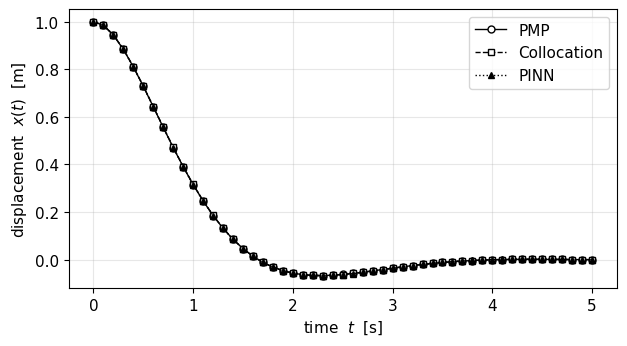

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Self-contained: re-read CSV from disk so this cell can run on its own.
_df = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))

# Subsample dense grid -> plotting grid.
_plot = _df.iloc[::PLOT_STRIDE].reset_index(drop=True)
tp = _plot['t'].values

# Style dictionary -- grayscale, distinguished by linestyle and marker.
STYLES = {
    'PMP'        : dict(color='black', linestyle='-',  marker='o', markersize=5, markerfacecolor='white', linewidth=1.0),
    'Collocation': dict(color='black', linestyle='--', marker='s', markersize=5, markerfacecolor='white', linewidth=1.0),
    'PINN'       : dict(color='black', linestyle=':',  marker='^', markersize=5, markerfacecolor='black', linewidth=1.0),
}
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(tp, _plot['x_pmp'],  label='PMP',         **STYLES['PMP'])
ax.plot(tp, _plot['x_col'],  label='Collocation', **STYLES['Collocation'])
ax.plot(tp, _plot['x_pinn'], label='PINN',        **STYLES['PINN'])
ax.set_xlabel('time  $t$  [s]')
ax.set_ylabel('displacement  $x(t)$  [m]')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_state_x.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_state_x.png'), dpi=200)
plt.show()

### Figure 2 -- Velocity $\dot x(t)$

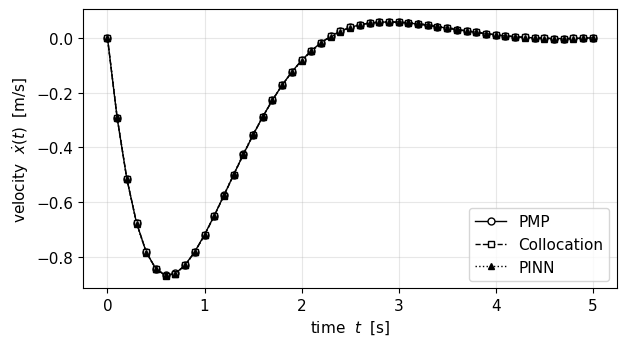

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Self-contained: re-read CSV from disk so this cell can run on its own.
_df = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))

# Subsample dense grid -> plotting grid.
_plot = _df.iloc[::PLOT_STRIDE].reset_index(drop=True)
tp = _plot['t'].values

# Style dictionary -- grayscale, distinguished by linestyle and marker.
STYLES = {
    'PMP'        : dict(color='black', linestyle='-',  marker='o', markersize=5, markerfacecolor='white', linewidth=1.0),
    'Collocation': dict(color='black', linestyle='--', marker='s', markersize=5, markerfacecolor='white', linewidth=1.0),
    'PINN'       : dict(color='black', linestyle=':',  marker='^', markersize=5, markerfacecolor='black', linewidth=1.0),
}
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(tp, _plot['v_pmp'],  label='PMP',         **STYLES['PMP'])
ax.plot(tp, _plot['v_col'],  label='Collocation', **STYLES['Collocation'])
ax.plot(tp, _plot['v_pinn'], label='PINN',        **STYLES['PINN'])
ax.set_xlabel('time  $t$  [s]')
ax.set_ylabel(r'velocity  $\dot{x}(t)$  [m/s]')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_state_v.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_state_v.png'), dpi=200)
plt.show()

### Figure 3 -- Optimal control $u(t)$

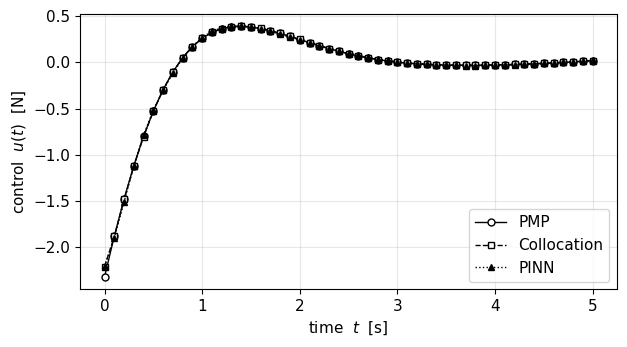

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Self-contained: re-read CSV from disk so this cell can run on its own.
_df = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))

# Subsample dense grid -> plotting grid.
_plot = _df.iloc[::PLOT_STRIDE].reset_index(drop=True)
tp = _plot['t'].values

# Style dictionary -- grayscale, distinguished by linestyle and marker.
STYLES = {
    'PMP'        : dict(color='black', linestyle='-',  marker='o', markersize=5, markerfacecolor='white', linewidth=1.0),
    'Collocation': dict(color='black', linestyle='--', marker='s', markersize=5, markerfacecolor='white', linewidth=1.0),
    'PINN'       : dict(color='black', linestyle=':',  marker='^', markersize=5, markerfacecolor='black', linewidth=1.0),
}
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(tp, _plot['u_pmp'],  label='PMP',         **STYLES['PMP'])
ax.plot(tp, _plot['u_col'],  label='Collocation', **STYLES['Collocation'])
ax.plot(tp, _plot['u_pinn'], label='PINN',        **STYLES['PINN'])
ax.set_xlabel('time  $t$  [s]')
ax.set_ylabel('control  $u(t)$  [N]')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_control_u.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_control_u.png'), dpi=200)
plt.show()

### Figure 4 -- Pointwise error $|x_{\mathrm{PINN}}(t) - x_{\mathrm{ref}}(t)|$

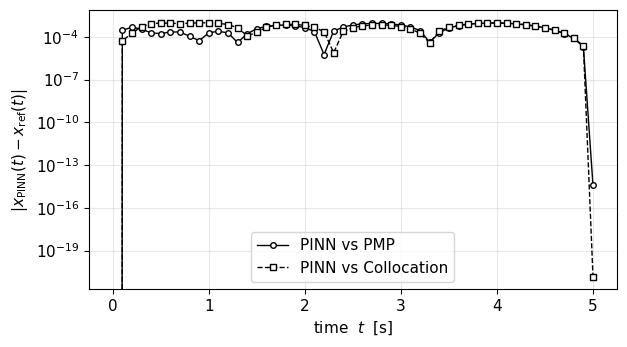

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Self-contained: re-read CSV from disk so this cell can run on its own.
_df = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))

# Subsample dense grid -> plotting grid.
_plot = _df.iloc[::PLOT_STRIDE].reset_index(drop=True)
tp = _plot['t'].values

# Style dictionary -- grayscale, distinguished by linestyle and marker.
STYLES = {
    'PMP'        : dict(color='black', linestyle='-',  marker='o', markersize=5, markerfacecolor='white', linewidth=1.0),
    'Collocation': dict(color='black', linestyle='--', marker='s', markersize=5, markerfacecolor='white', linewidth=1.0),
    'PINN'       : dict(color='black', linestyle=':',  marker='^', markersize=5, markerfacecolor='black', linewidth=1.0),
}
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.semilogy(tp, _plot['err_x_pinn_vs_pmp'],
            color='black', linestyle='-',  marker='o', markersize=4,
            markerfacecolor='white', linewidth=1.0, label='PINN vs PMP')
ax.semilogy(tp, _plot['err_x_pinn_vs_col'],
            color='black', linestyle='--', marker='s', markersize=4,
            markerfacecolor='white', linewidth=1.0, label='PINN vs Collocation')
ax.set_xlabel('time  $t$  [s]')
ax.set_ylabel(r'$|x_{\mathrm{PINN}}(t) - x_{\mathrm{ref}}(t)|$')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_error_x.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_error_x.png'), dpi=200)
plt.show()

### Figure 5 -- Pointwise error $|u_{\mathrm{PINN}}(t) - u_{\mathrm{ref}}(t)|$

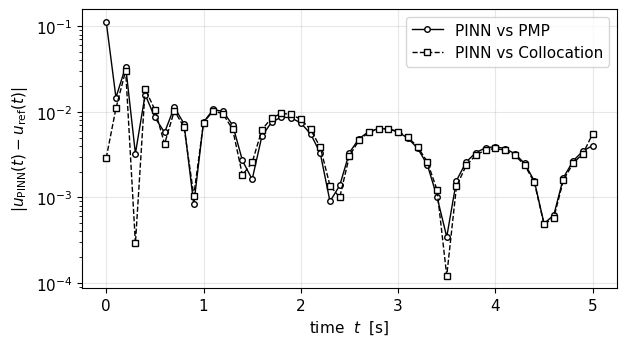

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Self-contained: re-read CSV from disk so this cell can run on its own.
_df = pd.read_csv(os.path.join(RESULTS_DIR, 'trajectories.csv'))

# Subsample dense grid -> plotting grid.
_plot = _df.iloc[::PLOT_STRIDE].reset_index(drop=True)
tp = _plot['t'].values

# Style dictionary -- grayscale, distinguished by linestyle and marker.
STYLES = {
    'PMP'        : dict(color='black', linestyle='-',  marker='o', markersize=5, markerfacecolor='white', linewidth=1.0),
    'Collocation': dict(color='black', linestyle='--', marker='s', markersize=5, markerfacecolor='white', linewidth=1.0),
    'PINN'       : dict(color='black', linestyle=':',  marker='^', markersize=5, markerfacecolor='black', linewidth=1.0),
}
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.semilogy(tp, _plot['err_u_pinn_vs_pmp'],
            color='black', linestyle='-',  marker='o', markersize=4,
            markerfacecolor='white', linewidth=1.0, label='PINN vs PMP')
ax.semilogy(tp, _plot['err_u_pinn_vs_col'],
            color='black', linestyle='--', marker='s', markersize=4,
            markerfacecolor='white', linewidth=1.0, label='PINN vs Collocation')
ax.set_xlabel('time  $t$  [s]')
ax.set_ylabel(r'$|u_{\mathrm{PINN}}(t) - u_{\mathrm{ref}}(t)|$')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_error_u.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_error_u.png'), dpi=200)
plt.show()

### Figure 6 -- PINN training loss history

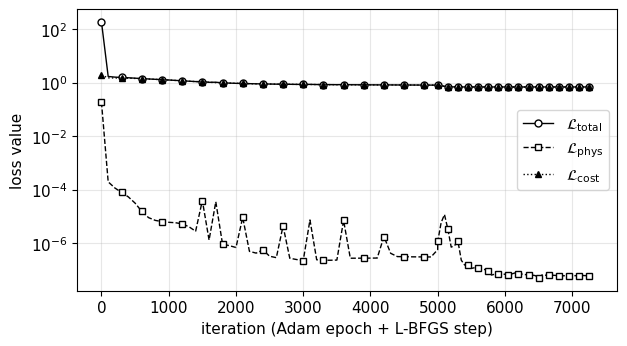

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_ldf = pd.read_csv(os.path.join(RESULTS_DIR, 'loss_history.csv'))

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
fig, ax = plt.subplots(figsize=(6.4, 3.6))

# Subsample markers to keep the plot uncluttered.
ne     = len(_ldf)
stride = max(1, ne // 25)

ax.semilogy(_ldf['epoch'], _ldf['L_total'],
            color='black', linestyle='-',  linewidth=1.0,
            marker='o', markevery=stride, markersize=5, markerfacecolor='white',
            label=r'$\mathcal{L}_{\mathrm{total}}$')
ax.semilogy(_ldf['epoch'], _ldf['L_phys'],
            color='black', linestyle='--', linewidth=1.0,
            marker='s', markevery=stride, markersize=5, markerfacecolor='white',
            label=r'$\mathcal{L}_{\mathrm{phys}}$')
ax.semilogy(_ldf['epoch'], _ldf['L_cost'],
            color='black', linestyle=':',  linewidth=1.0,
            marker='^', markevery=stride, markersize=5, markerfacecolor='black',
            label=r'$\mathcal{L}_{\mathrm{cost}}$')

ax.set_xlabel('iteration (Adam epoch + L-BFGS step)')
ax.set_ylabel('loss value')
ax.legend(loc='best', frameon=True)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'fig_loss_history.pdf'))
fig.savefig(os.path.join(FIGURES_DIR, 'fig_loss_history.png'), dpi=200)
plt.show()

## 13. Files produced

Inside `PROJECT_ROOT`:

```
results/
    trajectories.csv      # dense reference grid, all methods + errors
    loss_history.csv      # PINN loss history (Adam + L-BFGS)
figures/
    fig_state_x.pdf, .png
    fig_state_v.pdf, .png
    fig_control_u.pdf, .png
    fig_error_x.pdf, .png
    fig_error_u.pdf, .png
    fig_loss_history.pdf, .png
```

To regenerate any single figure without re-training the PINN, just re-run the corresponding figure cell -- it reads the CSV from disk and never depends on the training cell's in-memory state.